# PINN Black-Scholes

In [37]:
# Standard library imports
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

### Pathways

In [ ]:
# Pathways 
data_path = Path("..") / "data" / "generated" / "bs_collocation.parquet"
out_dir = Path("..") / "plots" / "eda"
out_dir.mkdir(parents=True, exist_ok=True)
out_path_pinn = out_dir / "pinn_bs.pdf"
out_path_loss = out_path = out_dir / "pinn_bs_loss.pdf"

### Global parameters

In [39]:
# Answer to the universe and everything
torch.manual_seed(42)

### Black-Scholes PINN Class

In [40]:
class BSPINN(nn.Module):
    def __init__(self, hidden_layers=3, neurons_per_layer=64):
        super(BSPINN, self).__init__()

        # Input layer: Takes (S, tau) -> 2 dimensions
        layers = [nn.Linear(2, neurons_per_layer), nn.Softplus()]

        # Hidden layers
        # Softplus or Tanh here since ReLU has a 2nd derivative of 0,
        # which would make V_SS completely vanish in our PDE
        for _ in range(hidden_layers):
            layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
            layers.append(nn.Softplus())

        # Outer layer: Returns V (Option Price) -> 1 dimension
        layers.append(nn.Linear(neurons_per_layer, 1))

        self.net = nn.Sequential(*layers)
    
    def forward(self, S, tau):
        # concatenate S and tau into a single input tensor
        x = torch.cat([S, tau], dim=1)
        return self.net(x)


### PDE Loss

In [41]:

# Function computes the Black-Scholes PDE residual
# using Automatic Differentiation
def pde_loss(model, S, tau, r, sigma):
    
    # (1) Forward pass to get option price V
    V = model(S, tau)

    # (2) First derivative dV/dS and dV/dtau
    # Make create_graph=True is critical so we can take 
    # the derivative of the derivative
    V_S = torch.autograd.grad(
        V, S,
        grad_outputs = torch.ones_like(V),
        create_graph = True
    )[0]

    V_tau = torch.autograd.grad(
        V, tau,
        grad_outputs = torch.ones_like(V),
        create_graph = True
    )[0]

    # (3) Second derivative d^2V/dS^2
    V_SS = torch.autograd.grad(
        V_S, S, 
        grad_outputs = torch.ones_like(V_S),
        create_graph = True
    )

    # (4) Construct the Black-Scholes residual
    pde_residual = V_tau - (0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V)

    # L_pde is the Mean Squared Error of the residual (want this to be 0)
    loss_pde = torch.mean(pde_residual**2)
    
    # Returning the PDE Loss
    return loss_pde

### Total Loss

In [42]:
# Formula calculating total loss
def total_loss(model, S_interior, tau_interior, S_boundary, tau_boundary, K, r, sigma):

    # (1) PDE Loss (L_pde)
    loss_pde = pde_loss(model, S_interior, tau_interior, r, sigma)

    # (2) Initial Condition Loss (L_ic)
    # At tau = 0 (maturity), the option price MUST equal the payoff max(S-K, 0)
    tau_zero = torch.zeros_like(S_interior)
    V_ic_pred = model(S_interior, tau_zero)

    # ReLU is here max(S-K, 0)
    V_ic_true = torch.relu(S_interior - K)
    
    # Finding the initial condition loss
    loss_ic = torch.mean((V_ic_pred - V_ic_true)**2)

    # (3) Boundary Condition Loss (L_bc)
    # E.g. at S = 0, a call option is worth 0
    S_zero = torch.zeros_like(tau_interior)
    V_bc_pred = model(S_zero, tau_interior)
    loss_bc = torch.mean((V_bc_pred - 0.0)**2)

    # Note: You'd also add a boundary for S -> infinity (V ≈ S - K * exp(-r*tau))

    # Total Loss
    total_loss = loss_pde + loss_ic + loss_bc
    
    # Returning total loss
    return total_loss


### Reading data

In [43]:
# Loading Parquet data file into a Pandas DataFrame
df_all = pd.read_parquet(data_path)

# Helper function to extract columns and turn them into gradient-tracking Tensors
def extract_tensors(df_subset):
    S_tensor = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).requires_grad_(True)
    tau_tensor = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).requires_grad_(True)
    return S_tensor, tau_tensor

# Interior points
df_interior = df_all[df_all['point_type'] == 'interior']
S_in, tau_in = extract_tensors(df_interior)

# Initial Condition points (Maturity)
df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, tau_ic = extract_tensors(df_ic)

# Boundary Condition points (S = 0)
df_bc = df_all[df_all['point_type'] == 'boundary_condition']
S_bc, tau_bc = extract_tensors(df_bc)

print(f"Read data from {data_path}")
print(f"Interior points: {len(S_in)}")
print(f"IC points: {len(S_ic)}")
print(f"BC points: {len(S_bc)}")

Read data from ..\data\generated\bs_collocation.parquet
Interior points: 10000
IC points: 2000
BC points: 2000


### Training a PINN

In [44]:
# Inputs
K = 100.0       # Strike price
r = 0.05        # Risk-free rate
sigma = 0.20    # Volatility

# Initiate the PINN and the Optimizer
# Using Softplus as defined earlier
model = BSPINN(hidden_layers=3, neurons_per_layer=64)

# Adam is the standard workhorse optimiser for Deep Learning
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Weigts for our loss function 
lambda_pde = 1.0
lambda_ic = 1.0
lambda_bc = 1.0

### Training Loop

In [45]:
# Inputs
epochs = 1000
print(f"Starting PINN learning at {epochs} epochs")

Starting PINN learning at 1000 epochs


In [46]:
# Initialize history lists
history = {
    'epoch': [],
    'total': [],
    'pde': [],
    'ic': [],
    'bc': []
}

# Print the table header
print(f"{'Epoch':>6} | {'Total Loss':>12} | {'PDE Loss':>12} | {'IC Loss':>12} | {'BC Loss':>12}")
print("-" * 66)

# Creating an array **once** before the loop starts
# to stop memory thrashing
grad_ones = torch.ones_like(S_in)

# Start that timer!
start_time = time.time()

# Looping over the epochs
for epoch in range(epochs):

    # Always zero the gradient before a new step
    optimizer.zero_grad()

    # Calculating the PDE loss
    V_pred = model(S_in, tau_in)

    # Automatic differentiation for the gradients using the pre-allocated array!
    V_S = torch.autograd.grad(V_pred, S_in, grad_outputs=grad_ones, create_graph=True)[0]
    V_tau = torch.autograd.grad(V_pred, tau_in, grad_outputs=grad_ones, create_graph=True)[0]
    V_SS = torch.autograd.grad(V_S, S_in, grad_outputs=grad_ones, create_graph=True)[0]

    # Black-Scholes PDE equation
    pde_residual = V_tau - (0.5 * sigma**2 * S_in**2 * V_SS + r * S_in * V_S - r * V_pred)
    loss_pde = torch.mean(pde_residual**2)

    # Calculating the initial condition loss
    # which is the payoff at maturity
    V_ic_pred = model(S_ic, tau_ic)

    # True payoff of a Call option is maX(S-K, 0)
    V_ic_true = torch.relu(S_ic - K)
    loss_ic = torch.mean((V_ic_pred - V_ic_true)**2)

    # Calculating the boundary condition loss at S=0
    V_bc_pred = model(S_bc, tau_bc)

    # A call option is worth 0 if the stock price is 0
    loss_bc = torch.mean((V_bc_pred - 0.0)**2)

    # Total Loss and Backpropagation
    loss = (lambda_pde * loss_pde) + (lambda_ic * loss_ic) + (lambda_bc * loss_bc)

    # Compute the gradients and update the neural 
    # network weights
    loss.backward()
    optimizer.step()

    # Record history for plotting
    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['bc'].append(loss_bc.item())

    # Print 20 rows of progress
    print_interval = max(1, epochs // 20)
    if epoch % print_interval == 0:
        print(f"{epoch:6d} | {loss.item():12.6f} | {loss_pde.item():12.6f} | {loss_ic.item():12.6f} | {loss_bc.item():12.6f}")

# Stop that timer!
end_time = time.time()

# Calculate minutes and seconds
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)

# Calculate dataset metrics
n_interior = len(S_in)
n_ic = len(S_ic)
n_bc = len(S_bc)
total_points = n_interior + n_ic + n_bc

# Printout training complete with the final metrics
print("-" * 66)
print(f"Training Complete! Trained {epochs} epochs in {minutes} minutes and {seconds} seconds.")
print(f"Dataset Size: {total_points:,} total points ({n_interior:,} Interior, {n_ic:,} IC, {n_bc:,} BC)")
print(f"Final Total Loss: {loss.item():.6f}")
print("=" * 66)


 Epoch |   Total Loss |     PDE Loss |      IC Loss |      BC Loss
------------------------------------------------------------------
     0 |   290.101349 |     0.000139 |   290.090881 |     0.010320
    50 |    98.996544 |     0.014722 |    98.048615 |     0.933203
   100 |    58.522015 |     0.071053 |    58.278431 |     0.172531
   150 |    28.969551 |     0.056830 |    28.912048 |     0.000673
   200 |    19.631523 |     0.297617 |    19.322269 |     0.011637
   250 |    13.566915 |     0.754229 |    12.806746 |     0.005939
   300 |     5.652897 |     1.178714 |     4.471286 |     0.002897
   350 |     5.684913 |     1.156055 |     4.523482 |     0.005376
   400 |     4.653058 |     1.029487 |     3.620732 |     0.002839
   450 |     3.051166 |     0.888136 |     2.161396 |     0.001634
   500 |     3.569411 |     0.914485 |     2.654317 |     0.000610
   550 |     2.993287 |     0.804388 |     2.188792 |     0.000108
   600 |     3.388169 |     0.611085 |     2.770646 |     0.00

### Pre-plotting

In [47]:
# Running another notebook including the analytical Black-Scholes
%run bs.ipynb

In [48]:
# Creating a clean 50x50 grid for plotting
S_plot = np.linspace(1e-5, 150.0, 50)
tau_plot = np.linspace(0.01, 1.0, 50)
S_grid, tau_grid = np.meshgrid(S_plot, tau_plot)

# Flatten the grids and convert to PyTorch
# tensors from the model
S_flat = torch.tensor(S_grid.flatten(), dtype=torch.float32).view(-1, 1)
tau_flat = torch.tensor(tau_grid.flatten(), dtype=torch.float32).view(-1, 1)

# Getting PINN predictions
# using torch.no_grad() because we are done training
# and dont need to track derivatives anymore
with torch.no_grad():
    V_pred_flat = model(S_flat, tau_flat).numpy()

# Reshape the flat predictions back into the 50x50
pinn_surface = V_pred_flat.reshape(S_grid.shape)

# Calculating true analyical prices
# assuming the bs function from earlier still
# in memory, passing tau_grid as T 
analytical_surface = bs(S=S_grid, K=K, T=tau_grid, r=r, sigma=sigma, type="call")

### Plotting the 3d surfaces

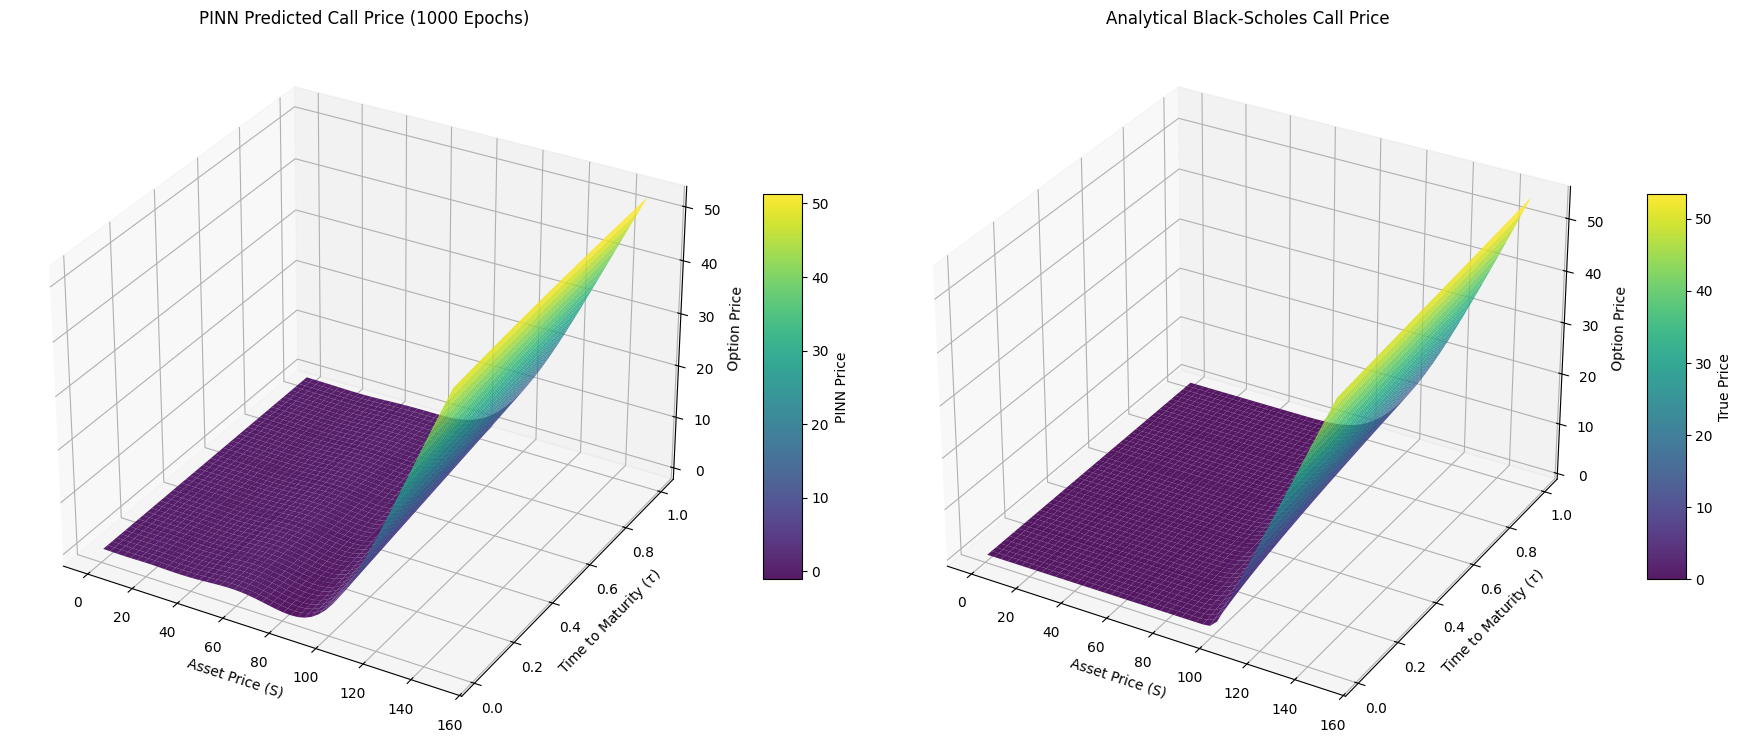

In [ ]:
# Setting up the figure
fig = plt.figure(figsize=(18, 8))

# Left plot: PINN prediction
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(S_grid, tau_grid, pinn_surface, cmap=cm.viridis, edgecolor='none', alpha=0.9)
ax1.set_title(f'PINN Predicted Call Price ({epochs} Epochs)')
ax1.set_xlabel('Asset Price (S)')
ax1.set_ylabel('Time to Maturity ($\\tau$)')
ax1.set_zlabel('Option Price')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='PINN Price')

# Right plot: True math
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(S_grid, tau_grid, analytical_surface, cmap=cm.viridis, edgecolor='none', alpha=0.9)
ax2.set_title('Analytical Black-Scholes Call Price')
ax2.set_xlabel('Asset Price (S)')
ax2.set_ylabel('Time to Maturity ($\\tau$)')
ax2.set_zlabel('Option Price')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='True Price')

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_pinn, bbox_inches="tight")
plt.show()

### Plotting some loss charts

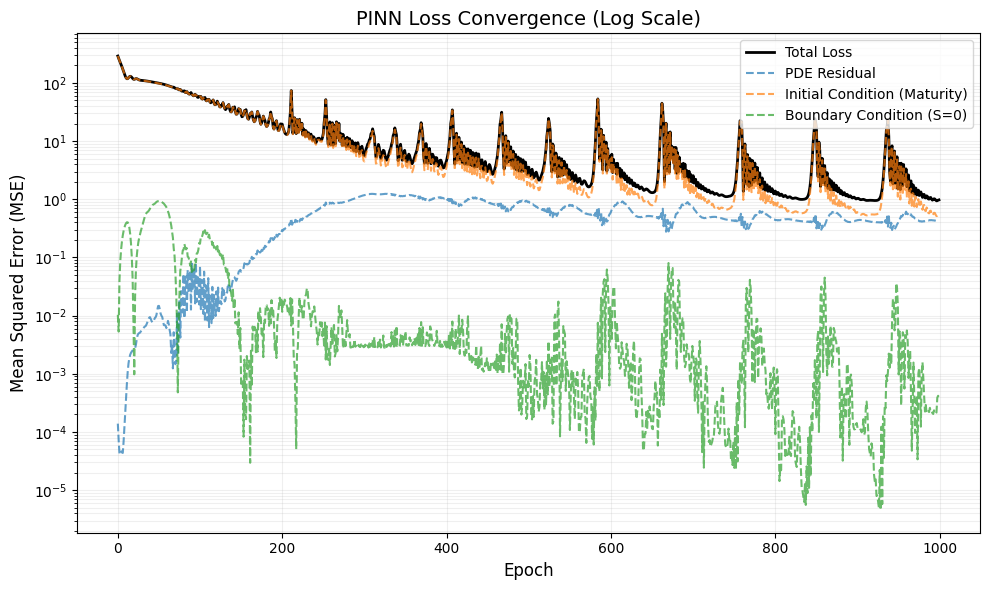

In [ ]:
# Setting up the figure
plt.figure(figsize=(10, 6))

# Plotting each component with a log scale on the Y-axis
plt.plot(history['epoch'], history['total'], label='Total Loss', color='black', linewidth=2)
plt.plot(history['epoch'], history['pde'], label='PDE Residual', linestyle='--', alpha=0.7)
plt.plot(history['epoch'], history['ic'], label='Initial Condition (Maturity)', linestyle='--', alpha=0.7)
plt.plot(history['epoch'], history['bc'], label='Boundary Condition (S=0)', linestyle='--', alpha=0.7)

# Setting the Y-axis to logarithmic scale
plt.yscale('log')

# Formatting the plot
plt.title('PINN Loss Convergence (Log Scale)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(frameon=True, loc='upper right')

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_loss, bbox_inches="tight")
plt.show()

### Financial metrics

In [ ]:
# Greeks

